<a href="https://colab.research.google.com/github/arya-arun-123/Blood_Cell_Classification_Model/blob/main/PCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LIBRARIES

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import  classification_report,confusion_matrix

# READ DATASET

In [ ]:
# dataset
filepath= "/content/drive/MyDrive/ICT AIML/Datasets/cnn proj/PBC_dataset_normal_DIB"

IMG_SIZE = 224

BATCH_SIZE = 32
EPOCH = 20
SEED = 42


In [ ]:
classes = sorted(os.listdir(filepath))

print("Classes Found:\n")

for cls in classes:
    class_path = os.path.join(filepath, cls)

    if os.path.isdir(class_path):

        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        print(f"{cls:<15} : {len(images)} images")

Classes Found:

basophil        : 1218 images
eosinophil      : 3117 images
erythroblast    : 1551 images
ig              : 2895 images
lymphocyte      : 1214 images
monocyte        : 1420 images
neutrophil      : 3330 images
platelet        : 2348 images


# CREATING TRAINING AND TESTING DATASET

In [ ]:
# TRAINING DATASET
# 70 % used for training

train_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE,
    shuffle=True
)

Found 17093 files belonging to 8 classes.
Using 11966 files for training.


In [ ]:
temp_ds = tf.keras.utils.image_dataset_from_directory(
    filepath,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 17093 files belonging to 8 classes.
Using 5127 files for validation.


In [ ]:
# VALIDATION AND TEST DATASET
# 15 % - validation datset
# 15 % - testing dataset
temp_batches = tf.data.experimental.cardinality(temp_ds)

val_ds = temp_ds.take(temp_batches // 2)
test_ds = temp_ds.skip(temp_batches // 2)

# AUTO TUNING

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# This allows to load next batch while training current batch

# AUGMENTATION

In [ ]:
# Makes changes in training data to prevent overfitting and improve generalization
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10)
])

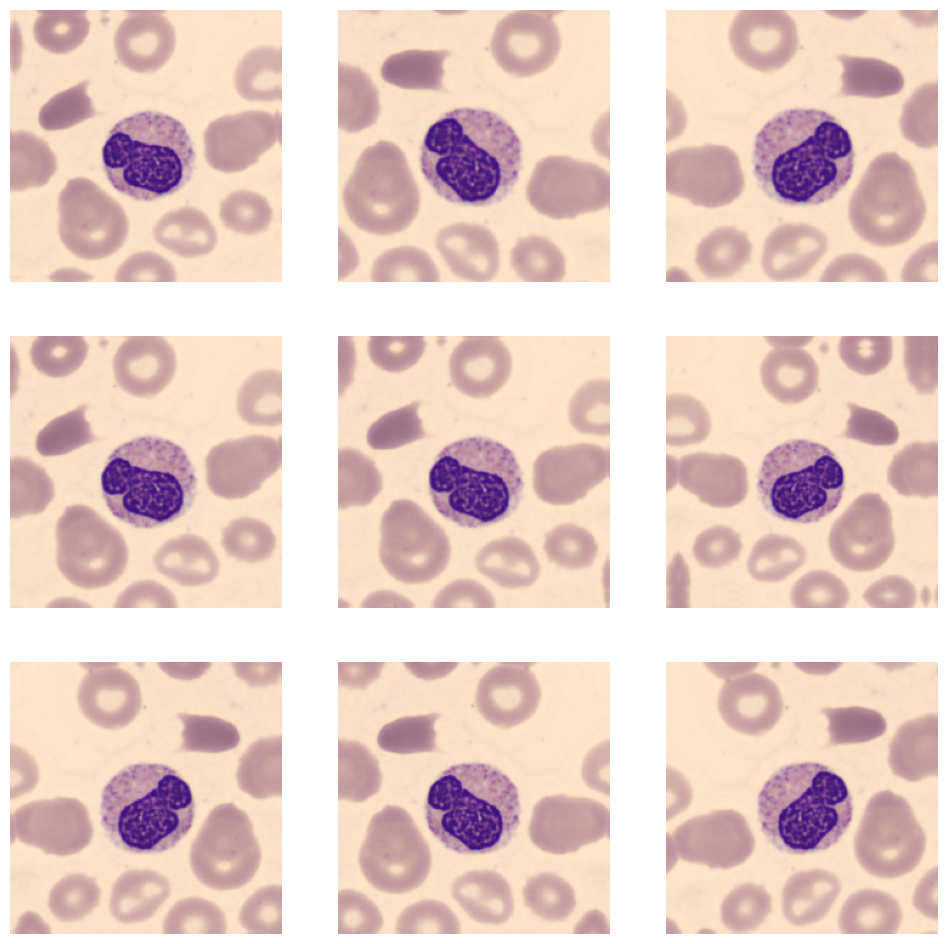

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.figure(figsize=(12, 12))

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))

        plt.imshow(augmented_image[0].numpy().astype("uint8"))

        plt.axis("off")

plt.show()

# NORMALIZATION

In [ ]:
normalization_layer = layers.Rescaling(1./255)

# MODEL BUILDING

In [ ]:
cnn_model = tf.keras.Sequential([


    data_augmentation,
    normalization_layer,
    # LAYER 1
    layers.Conv2D(
        filters = 32,
        kernel_size = (3,3),
        activation ='relu',
        padding ='same',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # LAYER 2
    layers.Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.25),

    # LAYER 3
    layers.Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Dropout(0.30),

    # OUTPUT LAYER
    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.50),

    layers.Dense(8, activation='softmax')

])

# COMPILING THE MODEL

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# CALLBACKS

In [ ]:
# Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Checkpointing
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: []


# MODEL TRAINING

In [ ]:
history = cnn_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 5,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/5
 24/374 ━━━━━━━━━━━━━━━━━━━━ 46:22 8s/step - accuracy: 0.3609 - loss: 1.6974